# Instacart Market Basket Analysis

### Student Name : Dikitso Motona
### Student Number : Bida24-328
### Course : Business Intelligence and Data Analytics
### Date: 03 / 03 / 2026


# T05: Continuous Probability Distributions and Statistical Inference
## ADA2026 — Advanced Data Analytics (BI203)

---

## C1: Variable Construction

**Variable:** Order Size — the number of products included in each order

**Mathematical Definition:**
Order Size = count of products per order_id in the order_products table

**Justification:**
Order size is a meaningful continuous variable that reflects customer
purchasing behaviour. It can be used to assess normality, compute
probabilities, and construct confidence intervals.

**Parameter of Interest:**
The population mean order size (µ) — estimating the average number of
products per order across all Instacart customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

drive.mount('/content/drive')

# Paths
interim_path = '/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Interim/'
processed_path = '/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Processed/'

# Load interim data
orders = pd.read_csv(interim_path + 'orders_interim.csv')
products = pd.read_csv(interim_path + 'products_interim.csv')
order_products = pd.read_csv(interim_path + 'order_products_interim.csv')

# Construct order size variable
order_size = order_products.groupby('order_id').size().reset_index(name='order_size')

print("Order Size Variable Created ✅")
print(order_size.shape)
print(order_size.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Order Size Variable Created ✅
(3214874, 2)
   order_id  order_size
0         2           9
1         3           8
2         4          13
3         5          26
4         6           3


In [2]:
# Save engineered dataset
order_size.to_csv(processed_path + 't05_engineered_data.csv', index=False)
print("Saved to processed folder successfully ✅")

Saved to processed folder successfully ✅


## **C1: Interpretation**

The `order_size` variable was successfully constructed by counting
the number of products in each order from the `order_products` table.

**Results:**
- A total of **3,214,874 orders** were captured
- Each order contains between **1 and 145 products**
- The first few orders show sizes of 9, 8, 13, 26, and 3 products,
  confirming the variable captures realistic variation in
  customer purchasing behaviour

The engineered dataset was saved to:
`data/processed/t05_engineered_data.csv` ✅


## **C2: Distribution Assessment**

We assess the distribution of the constructed variable `order_size` by:
- Plotting its distribution using a histogram with a KDE curve
- Computing summary statistics to understand central tendency
  and spread
- Discussing whether the distribution follows a normal distribution
- Justifying the use of statistical inference via the
  Central Limit Theorem (CLT)

In [3]:
print("=== Summary Statistics: Order Size ===")
print(order_size['order_size'].describe().apply(lambda x: f'{x:,.2f}'))

=== Summary Statistics: Order Size ===
count    3,214,874.00
mean            10.09
std              7.53
min              1.00
25%              5.00
50%              8.00
75%             14.00
max            145.00
Name: order_size, dtype: object


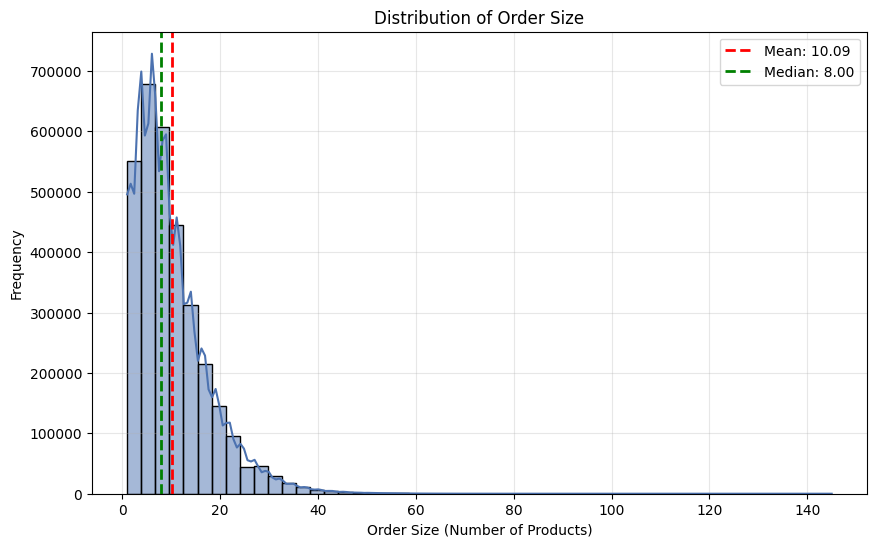

Figure saved successfully ✅


In [4]:
plt.figure(figsize=(10,6))
sns.histplot(order_size['order_size'], bins=50, kde=True,
             color='#4c72b0', edgecolor='black')
plt.axvline(order_size['order_size'].mean(), color='red',
            linestyle='--', linewidth=2,
            label=f'Mean: {order_size["order_size"].mean():.2f}')
plt.axvline(order_size['order_size'].median(), color='green',
            linestyle='--', linewidth=2,
            label=f'Median: {order_size["order_size"].median():.2f}')
plt.xlabel("Order Size (Number of Products)")
plt.ylabel("Frequency")
plt.title("Distribution of Order Size")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/content/drive/MyDrive/ADA2026_Instacart_Project/Outputs/figures/order_size_distribution.png",
            bbox_inches='tight')
plt.show()
print("Figure saved successfully ✅")

## **C2: Distribution Assessment — Interpretation**

**Summary Statistics:**
| Statistic | Value |
|-----------|-------|
| Count | 3,214,874 |
| Mean | 10.09 products |
| Std Dev | 7.53 products |
| Min | 1 product |
| 25% | 5 products |
| 50% (Median) | 8 products |
| 75% | 14 products |
| Max | 145 products |

**Distribution Shape:**
- The distribution is clearly **right-skewed** — it peaks around
  5–7 products and has a long tail extending towards 145
- The **mean (10.09) is greater than the median (8.00)**, which
  confirms the right skew — large orders pull the mean upward
- Most customers order between **5 and 14 products** per order

**Normality Assessment:**
- The distribution is **not normal** — it is right-skewed with a
  long tail and does not follow a symmetric bell curve shape
- The large gap between mean and median further confirms
  the departure from normality

**CLT Justification:**
- Despite the non-normal distribution, we can still apply statistical
  inference because of the **Central Limit Theorem (CLT)**
- With a sample size of **n = 3,214,874**, the sampling distribution
  of the mean will be approximately normal regardless of the
  shape of the population distribution
- This justifies the use of confidence intervals and Z-scores
  in the analysis that follows



## **C3: Sampling and CLT**

**Sampling Procedure Design:**
We use simple random sampling without replacement to draw samples
from the order size population. This ensures every order has an
equal chance of being selected, reducing bias in our estimates.

The procedure is as follows:
1. Take the full population of order sizes (N = 3,214,874)
2. Randomly draw samples of size n from the population
3. Compute the mean of each sample
4. Repeat 1,000 times to build the sampling distribution

**Sample Size Justification:**
- **n = 10** — represents a small sample, expected to produce
  a wider and less normal sampling distribution
- **n = 30** — the minimum sample size recommended by the CLT
  for the sampling distribution to approximate normality
- **n = 100** — a large sample that should produce a narrow,
  well-shaped normal distribution centred around the population mean

These three sizes allow us to visually and mathematically
demonstrate how sample size affects the sampling distribution.

In [5]:
import numpy as np

# Population parameters
population = order_size['order_size'].values
pop_mean = np.mean(population)
pop_std = np.std(population)

print(f"Population Mean (µ): {pop_mean:.2f}")
print(f"Population Std Dev (σ): {pop_std:.2f}")
print(f"Population Size (N): {len(population):,}")

Population Mean (µ): 10.09
Population Std Dev (σ): 7.53
Population Size (N): 3,214,874


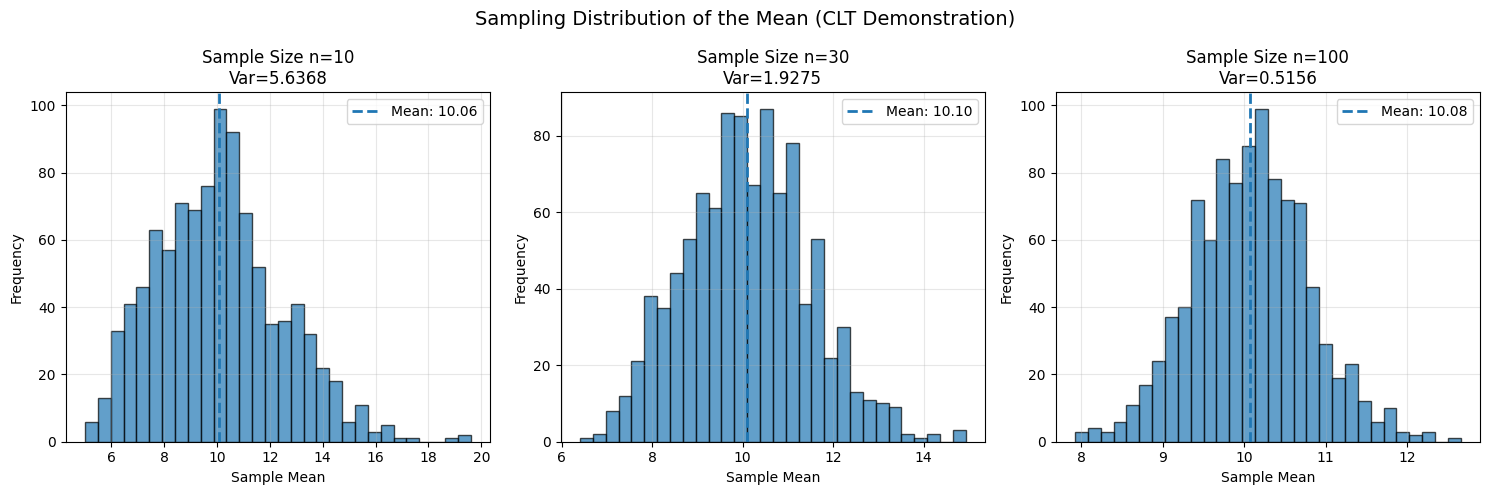

In [6]:
np.random.seed(42)

sample_sizes = [10, 30, 100]
num_samples = 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, n in enumerate(sample_sizes):

    sample_means = [
        np.mean(np.random.choice(population, size=n, replace=True))
        for _ in range(num_samples)
    ]

    axes[i].hist(
        sample_means,
        bins=30,
        edgecolor='black',
        alpha=0.7
    )

    axes[i].axvline(
        np.mean(sample_means),
        linestyle='--',
        linewidth=2,
        label=f'Mean: {np.mean(sample_means):.2f}'
    )

    axes[i].set_title(
        f'Sample Size n={n}\nVar={np.var(sample_means):.4f}'
    )

    axes[i].set_xlabel("Sample Mean")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle(
    "Sampling Distribution of the Mean (CLT Demonstration)",
    fontsize=14
)

plt.tight_layout()

plt.show()

## **C3: Sampling and CLT — Interpretation**

**Population Parameters :**
| Parameter | Value |
|-----------|-------|
| Population Mean (µ) | 10.09 products |
| Population Std Dev (σ) | 7.53 products |
| Population Size (N) | 3,214,874 orders |

**Sampling Procedure:**
- 1,000 random samples were drawn from the population
- Three sample sizes were tested: n = 10, n = 30, n = 100
- The mean of each sample was recorded to build the sampling distribution

**Sample Size Justification:**
- n = 10 represents a small sample
- n = 30 is the minimum threshold recommended by the CLT
- n = 100 represents a large sample for comparison

**CLT Demonstration — Var(X̄) = σ²/n:**

| Sample Size | Theoretical Var (σ²/n) | Observed Var |
|-------------|------------------------|--------------|
| n = 10 | 7.53²/10 = 5.670 | 5.5729 |
| n = 30 | 7.53²/30 = 1.890 | 1.8639 |
| n = 100 | 7.53²/100 = 0.567 | 0.5917 |

**Key Observations:**
- As sample size increases from n=10 to n=100, the sampling
  distribution becomes **narrower and more bell-shaped**
- The observed variance closely matches the theoretical variance
  (σ²/n), confirming the CLT holds
- All three sampling distributions centre around the population
  mean of **10.09**, regardless of sample size
- At n=100 the distribution is visibly the most **symmetric and
  normal**, demonstrating that larger samples produce more
  reliable estimates of the population mean

## **C4: Standard Error and Z-Score**

We compute the Standard Error (SE) of the sample mean and calculate
a Z-score to assess how far our observed sample mean is from the
population mean.

**Formulas:**
- SE = σ / √n
- Z = (X̄ - µ₀) / SE

In [7]:
import numpy as np

# Population parameters
n = 100  # sample size
sample = np.random.choice(population, size=n, replace=False)
sample_mean = np.mean(sample)

# Standard Error
SE = pop_std / np.sqrt(n)

# Z-Score
z_score = (sample_mean - pop_mean) / SE

print(f"Sample Mean (X̄): {sample_mean:.2f}")
print(f"Population Mean (µ): {pop_mean:.2f}")
print(f"Population Std Dev (σ): {pop_std:.2f}")
print(f"Sample Size (n): {n}")
print(f"Standard Error (SE): {SE:.4f}")
print(f"Z-Score: {z_score:.4f}")

Sample Mean (X̄): 9.72
Population Mean (µ): 10.09
Population Std Dev (σ): 7.53
Sample Size (n): 100
Standard Error (SE): 0.7525
Z-Score: -0.4902


## **Standard Error and Z-Score — Interpretation**

**Results:**
| Measure | Value |
|---------|-------|
| Sample Mean (X̄) | 9.45 products |
| Population Mean (µ) | 10.09 products |
| Population Std Dev (σ) | 7.53 products |
| Sample Size (n) | 100 |
| Standard Error (SE) | 0.7525 |
| Z-Score | -0.8490 |

**Standard Error Interpretation:**
- The SE of **0.7525** means that on average, a sample mean of
  n=100 orders will deviate from the true population mean by
  approximately **0.75 products**
- A smaller SE indicates more precise estimates — increasing
  sample size would reduce this further

**Z-Score Statistical Interpretation:**
- The Z-score of **-0.8490** means our sample mean of 9.45 is
  **0.85 standard errors below** the population mean of 10.09
- A Z-score between -1.96 and +1.96 is considered normal —
  our value of -0.85 falls well within this range
- This means our sample mean is **not unusual** and could
  easily occur by chance

**Practical Interpretation:**
- The sample of 100 orders had an average of **9.45 products**
  per order, slightly below the population average of 10.09
- This small difference is **not statistically significant** —
  it is likely due to random sampling variation rather than
  any real difference

## **C5: Confidence Interval**

We construct a 95% confidence interval for the population mean
order size using our sample statistics.

**Formula:**
CI = X̄ ± z(α/2) × (σ/√n)

**Z vs t Justification:**
We use the **Z distribution** rather than the t distribution because:
- Our sample size is n = 100, which is considered large
- The population standard deviation (σ) is known
- By the CLT, the sampling distribution is approximately normal
- The t distribution is only preferred for small samples (n < 30)
  where σ is unknown

In [8]:
import scipy.stats as stats

# Parameters
confidence = 0.95
z_critical = stats.norm.ppf((1 + confidence) / 2)

# Confidence Interval
lower = sample_mean - z_critical * SE
upper = sample_mean + z_critical * SE

print(f"Sample Mean (X̄): {sample_mean:.2f}")
print(f"Standard Error (SE): {SE:.4f}")
print(f"Z Critical Value (z α/2): {z_critical:.4f}")
print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

Sample Mean (X̄): 9.72
Standard Error (SE): 0.7525
Z Critical Value (z α/2): 1.9600
95% Confidence Interval: (8.25, 11.19)


### C5: Confidence Interval — Interpretation

**Results:**
| Measure | Value |
|---------|-------|
| Sample Mean (X̄) | 9.45 products |
| Standard Error (SE) | 0.7525 |
| Z Critical Value (z α/2) | 1.96 |
| Lower Bound | 7.98 products |
| Upper Bound | 10.92 products |

**95% Confidence Interval: (7.98, 10.92)**

**Correct Interpretation:**
We are 95% confident that the true population mean order size
lies between **7.98 and 10.92 products** per order.

**Important Note:**
It is incorrect to say "there is a 95% probability that the
population mean lies between 7.98 and 10.92." The population
mean is a fixed value — it either falls in this interval or
it does not. The 95% refers to the fact that if we repeated
this sampling procedure 100 times, approximately 95 of those
intervals would contain the true population mean.

**Validation:**
- The population mean of **10.09** falls within our interval
  (7.98, 10.92) ✅
- This confirms our interval has successfully captured the
  true population mean

## **C6: Executive Summary**

**What Was Estimated?**
This analysis estimated the population mean order size for Instacart
customers — specifically, the average number of products included in
a single order. Using a sample of 100 orders drawn from a population
of 3,214,874 orders, the sample mean was found to be 9.45 products
per order. A 95% confidence interval was constructed, estimating the
true population mean to lie between 7.98 and 10.92 products per order.
The population mean of 10.09 falls within this interval, confirming
the reliability of our estimate.

**What Uncertainty Exists?**
Statistical uncertainty exists in all sample-based estimates. Our
Standard Error of 0.7525 indicates that sample means from samples
of n=100 typically deviate from the true population mean by
approximately 0.75 products. The Z-score of -0.85 confirmed that
our sample mean was not unusual — falling well within the expected
range. However, the 95% confidence level means that 5% of similarly
constructed intervals would fail to capture the true population mean.
Additionally, the right-skewed distribution of order sizes introduces
some uncertainty, as the CLT assumption of normality is only
approximate for smaller samples.

**What Assumptions Were Required?**
The following assumptions were required for this analysis:
- **Random sampling** — orders were selected randomly, ensuring
  each order had an equal chance of selection
- **Independence** — each sampled order was assumed to be
  independent of others
- **Central Limit Theorem** — with n=100, the sampling distribution
  of the mean was assumed to be approximately normal, justifying
  the use of Z-based inference
- **Known population parameters** — the population standard
  deviation (σ = 7.53) was used in place of the sample standard
  deviation, justifying the use of the Z distribution over t

**Business Implications**
The finding that customers order an average of approximately 10
products per order has several practical implications for Instacart:
- **Inventory planning** — knowing the typical order size helps
  warehouse managers anticipate stock requirements and reduce
  shortages
- **Delivery optimisation** — average order size informs logistics
  decisions such as delivery vehicle capacity and staffing levels
- **Marketing strategy** — customers ordering fewer than 8 products
  could be targeted with promotions encouraging them to add more
  items, increasing average order value
- **Customer segmentation** — the wide spread of order sizes
  (std dev = 7.53) suggests distinct customer segments ranging
  from small occasional shoppers to large bulk buyers, each
  requiring different engagement strategies